# 06 - Bagging & Boosting Model Comparison

This notebook extends the modeling work from `05_ML_model.ipynb` (4-class) and
`05_ML_model_3.ipynb` (3-class). Those notebooks already trained **Random Forest**
and **XGBoost** -- which, importantly, are already one representative of each
ensemble family:

- **Random Forest = Bagging** (bootstrap-aggregated decision trees + feature randomness)
- **XGBoost = Boosting** (sequential, residual-fitting trees)

So "adding bagging and boosting" really means **broadening each family** with more
algorithms, so the comparison isn't just "one bagging model vs one boosting model"
but a genuine paradigm-level comparison:

| Family | Algorithms in this notebook |
|---|---|
| **Bagging** | Random Forest *(recap)*, **Bagging Classifier** (bootstrap-aggregated Decision Trees), **Extra Trees** (extremely randomized trees) |
| **Boosting** | XGBoost *(recap)*, **AdaBoost**, **Gradient Boosting**, **LightGBM**, **CatBoost** |

CatBoost was explicitly listed as "Future Work" in the README -- this notebook delivers it.

Both label schemes from the original project are evaluated, so results stay
comparable with the existing README tables:
- **4-Class**: Not-exposed / At Risk-Concerned / Vulnerable / High Vulnerability
- **3-Class**: Low Risk / Medium Risk / High Risk (the reformulation that performed best originally)

All results are logged to `../outputs/results/model_results.csv`, a shared ledger
that notebook `08_final_comparison.ipynb` reads to build the complete comparison
across *every* model in the project -- MLP, tree ensembles, and (next) the CNN.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import time

from sklearn.ensemble import (
    RandomForestClassifier, BaggingClassifier, ExtraTreesClassifier,
    AdaBoostClassifier, GradientBoostingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_sample_weight
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

os.makedirs("../outputs/figures", exist_ok=True)
os.makedirs("../outputs/models", exist_ok=True)
os.makedirs("../outputs/results", exist_ok=True)

X_train = pd.read_csv("../data/processed/X_train.csv")
X_test  = pd.read_csv("../data/processed/X_test.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()
y_test  = pd.read_csv("../data/processed/y_test.csv").values.ravel()

def remap(y):
    """Same collapse used in 05_ML_model_3.ipynb:
       0=Not-exposed -> 0=Low Risk
       1=At Risk/Concerned -> 1=Medium Risk
       2=Vulnerable, 3=High Vulnerability -> 2=High Risk"""
    return np.where(y <= 1, y, 2)

y_train_3, y_test_3 = remap(y_train), remap(y_test)

class_names_4 = ['Not-exposed', 'At Risk / Concerned', 'Vulnerable', 'High Vulnerability']
class_names_3 = ['Low Risk', 'Medium Risk', 'High Risk']

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"4-class label counts (train): {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"3-class label counts (train): {dict(zip(*np.unique(y_train_3, return_counts=True)))}")

X_train: (44806, 23)
X_test:  (11202, 23)
4-class label counts (train): {0: 7470, 1: 14839, 2: 7536, 3: 14961}
3-class label counts (train): {0: 7470, 1: 14839, 2: 22497}


In [2]:
RESULTS_PATH = "../outputs/results/model_results.csv"

def log_result(model, family, num_classes, train_acc, test_acc, macro_f1, weighted_f1, notebook, notes=""):
    """Append/replace a row in the shared results ledger used by the final
    comparison notebook (08_final_comparison.ipynb). Upserts on (model, num_classes)
    so re-running a cell doesn't create duplicate rows."""
    os.makedirs(os.path.dirname(RESULTS_PATH), exist_ok=True)
    row = {
        "model": model, "family": family, "num_classes": num_classes,
        "train_accuracy": round(float(train_acc), 4), "test_accuracy": round(float(test_acc), 4),
        "macro_f1": round(float(macro_f1), 4), "weighted_f1": round(float(weighted_f1), 4),
        "notebook": notebook, "notes": notes,
    }
    if os.path.exists(RESULTS_PATH):
        df = pd.read_csv(RESULTS_PATH)
        df = df[~((df["model"] == model) & (df["num_classes"] == num_classes))]
        df = pd.concat([df, pd.DataFrame([row])], ignore_index=True)
    else:
        df = pd.DataFrame([row])
    df.to_csv(RESULTS_PATH, index=False)
    return df

# Seed the ledger with the results already obtained in earlier notebooks, so the
# final comparison can bring every model -- old and new -- onto one table.
# NOTE: 05_ML_model.ipynb hardcoded mlp_macro_f1 = 0.35 with a "replace with actual
# value" comment that was never followed up on. The real number, straight from
# 03_mlp_model.ipynb's own classification_report output, is macro avg f1 = 0.46
# (weighted avg f1 = 0.49) -- that's the corrected value logged below.
log_result("MLP", "Deep Learning (Tabular)", 4, 0.5421, 0.5267, 0.46, 0.49,
           "03_mlp_model.ipynb", "Test accuracy/loss reproduced from cached notebook output.")

print("Results ledger initialized ->", RESULTS_PATH)

Results ledger initialized -> ../outputs/results/model_results.csv


## Model zoo & how class imbalance is handled

All eight models share the same `X_train` / `X_test` (23 engineered features, one-hot
land-use, standardized) so the comparison is apples-to-apples. Class imbalance
(High Risk / Vulnerable are much more common than Not-exposed) is handled per model
using whatever mechanism that library actually supports, mirroring how the original
notebook used `class_weight="balanced"` for Random Forest:

| Model | Family | Imbalance handling |
|---|---|---|
| Random Forest | Bagging | `class_weight="balanced"` |
| Bagging (Decision Tree) | Bagging | base estimator `class_weight="balanced"` |
| Extra Trees | Bagging | `class_weight="balanced"` |
| XGBoost | Boosting | none (matches original notebook exactly, for a clean recap) |
| AdaBoost | Boosting | base estimator `class_weight="balanced"` |
| Gradient Boosting | Boosting | `sample_weight` from `compute_sample_weight("balanced", ...)` (sklearn's GBM has no native `class_weight`) |
| LightGBM | Boosting | `class_weight="balanced"` |
| CatBoost | Boosting | `auto_class_weights="Balanced"` |

None of these were grid-searched -- one reasonable, fixed configuration per model,
same philosophy the original notebook used for Random Forest / XGBoost.

In [3]:
MODEL_BUILDERS = {
    "Random Forest": ("Bagging", False, lambda: RandomForestClassifier(
        n_estimators=300, max_depth=None, min_samples_split=5, min_samples_leaf=2,
        class_weight="balanced", random_state=42, n_jobs=-1)),
    "Bagging (Decision Tree)": ("Bagging", False, lambda: BaggingClassifier(
        estimator=DecisionTreeClassifier(class_weight="balanced", random_state=42),
        n_estimators=300, max_samples=0.8, random_state=42, n_jobs=-1)),
    "Extra Trees": ("Bagging", False, lambda: ExtraTreesClassifier(
        n_estimators=300, max_depth=None, min_samples_split=5, min_samples_leaf=2,
        class_weight="balanced", random_state=42, n_jobs=-1)),
    "XGBoost": ("Boosting", False, lambda: xgb.XGBClassifier(
        n_estimators=500, max_depth=6, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
        objective='multi:softprob', eval_metric='mlogloss', random_state=42, n_jobs=-1)),
    "AdaBoost": ("Boosting", False, lambda: AdaBoostClassifier(
        estimator=DecisionTreeClassifier(max_depth=3, class_weight="balanced"),
        n_estimators=400, learning_rate=0.5, random_state=42)),
    "Gradient Boosting": ("Boosting", True, lambda: GradientBoostingClassifier(
        n_estimators=250, max_depth=3, learning_rate=0.1, subsample=0.8, random_state=42)),
    "LightGBM": ("Boosting", False, lambda: lgb.LGBMClassifier(
        n_estimators=300, max_depth=8, learning_rate=0.05, class_weight="balanced",
        random_state=42, n_jobs=-1, verbosity=-1)),
    "CatBoost": ("Boosting", False, lambda: CatBoostClassifier(
        iterations=500, depth=6, learning_rate=0.1, auto_class_weights="Balanced",
        random_state=42, verbose=False)),
}

def train_and_evaluate(name, num_classes, Xtr, ytr, Xte, yte, cnames, notebook_tag):
    family, use_sample_weight, builder = MODEL_BUILDERS[name]
    t0 = time.time()
    model = builder()
    if use_sample_weight:
        sw = compute_sample_weight("balanced", ytr)
        model.fit(Xtr, ytr, sample_weight=sw)
    else:
        model.fit(Xtr, ytr)
    dt = time.time() - t0

    train_pred, test_pred = model.predict(Xtr), model.predict(Xte)
    train_acc = accuracy_score(ytr, train_pred)
    test_acc  = accuracy_score(yte, test_pred)
    macro_f1  = f1_score(yte, test_pred, average="macro")
    weighted_f1 = f1_score(yte, test_pred, average="weighted")

    print(f"[{num_classes}-class][{name}] fit={dt:.1f}s  "
          f"train_acc={train_acc:.4f}  test_acc={test_acc:.4f}  "
          f"macro_f1={macro_f1:.4f}  weighted_f1={weighted_f1:.4f}")

    log_result(name, family, num_classes, train_acc, test_acc, macro_f1, weighted_f1, notebook_tag)

    fname = name.lower().replace(" ", "_").replace("(", "").replace(")", "")
    with open(f"../outputs/models/{fname}_{num_classes}class.pkl", "wb") as f:
        pickle.dump(model, f)

    return model, test_pred

## 4-Class Experiments

Reproducing the original label scheme from `05_ML_model.ipynb` first, so the new
algorithms sit next to the numbers already in the README (RF 57.32% / XGBoost 54.12%
test accuracy).

In [4]:
MODEL_ORDER = ["Random Forest", "Bagging (Decision Tree)", "Extra Trees",
               "XGBoost", "AdaBoost", "Gradient Boosting", "LightGBM", "CatBoost"]

models_4class = {}
for name in MODEL_ORDER:
    model, _ = train_and_evaluate(name, 4, X_train, y_train, X_test, y_test,
                                   class_names_4, "06_bagging_boosting_models.ipynb")
    models_4class[name] = model

[4-class][Random Forest] fit=37.8s  train_acc=0.9863  test_acc=0.5696  macro_f1=0.5480  weighted_f1=0.5600
[4-class][Bagging (Decision Tree)] fit=128.2s  train_acc=1.0000  test_acc=0.5695  macro_f1=0.5384  weighted_f1=0.5540
[4-class][Extra Trees] fit=10.6s  train_acc=0.9487  test_acc=0.5591  macro_f1=0.5540  weighted_f1=0.5589
[4-class][XGBoost] fit=12.3s  train_acc=0.6818  test_acc=0.5378  macro_f1=0.4888  weighted_f1=0.5089
[4-class][AdaBoost] fit=1.2s  train_acc=0.4403  test_acc=0.4392  macro_f1=0.4302  weighted_f1=0.4301
[4-class][Gradient Boosting] fit=106.1s  train_acc=0.5299  test_acc=0.4798  macro_f1=0.4920  weighted_f1=0.4842
[4-class][LightGBM] fit=6.4s  train_acc=0.6205  test_acc=0.5075  macro_f1=0.5173  weighted_f1=0.5115
[4-class][CatBoost] fit=17.1s  train_acc=0.5709  test_acc=0.5009  macro_f1=0.5118  weighted_f1=0.5057


In [8]:
ledger = pd.read_csv(RESULTS_PATH)
df4 = ledger[ledger.num_classes == 4].sort_values("test_accuracy", ascending=False).reset_index(drop=True)
df4["gap"] = (df4["train_accuracy"] - df4["test_accuracy"]).round(4)
print(df4[["model","family","train_accuracy","test_accuracy","macro_f1","weighted_f1","gap"]].to_string(index=False))

                  model   family  train_accuracy  test_accuracy  macro_f1  weighted_f1    gap
          Random Forest  Bagging          0.9863         0.5696    0.5480       0.5600 0.4167
Bagging (Decision Tree)  Bagging          1.0000         0.5695    0.5384       0.5540 0.4305
            Extra Trees  Bagging          0.9487         0.5591    0.5540       0.5589 0.3896
                XGBoost Boosting          0.6818         0.5378    0.4888       0.5089 0.1440
               LightGBM Boosting          0.6205         0.5075    0.5173       0.5115 0.1130
               CatBoost Boosting          0.5709         0.5009    0.5118       0.5057 0.0700
      Gradient Boosting Boosting          0.5299         0.4798    0.4920       0.4842 0.0501
               AdaBoost Boosting          0.4403         0.4392    0.4302       0.4301 0.0011


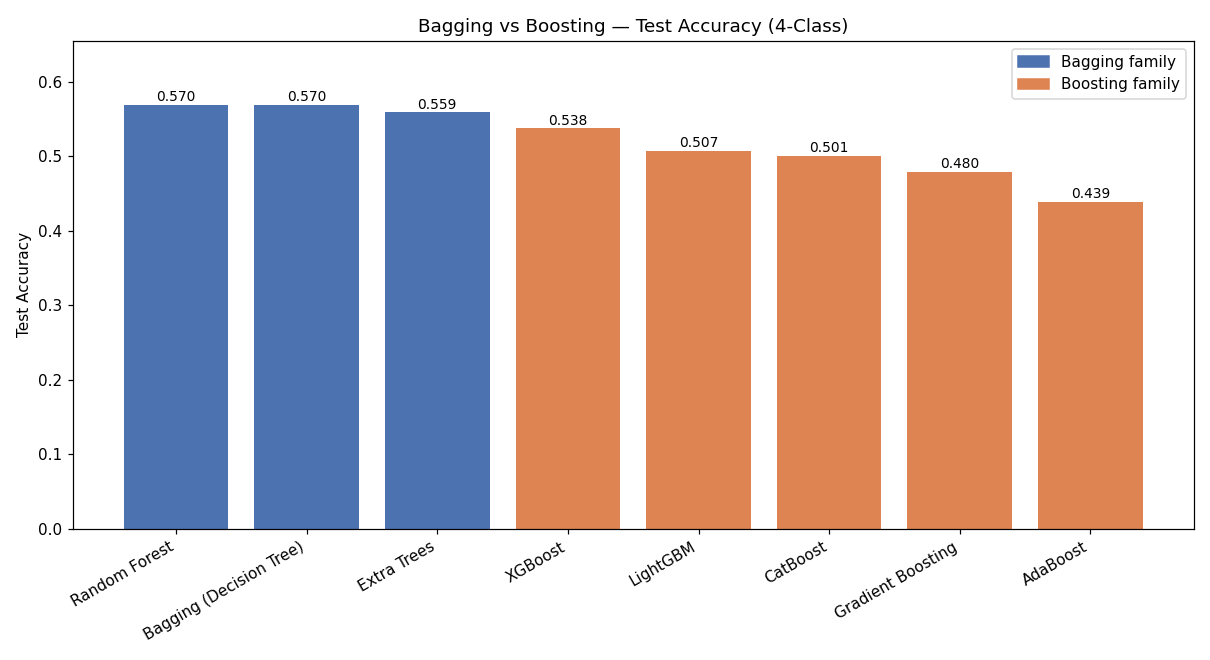

In [9]:
fig, ax = plt.subplots(figsize=(11,6))
colors = ['#4C72B0' if f=='Bagging' else '#DD8452' for f in df4['family']]
bars = ax.bar(df4['model'], df4['test_accuracy'], color=colors)
for b, v in zip(bars, df4['test_accuracy']):
    ax.text(b.get_x()+b.get_width()/2, v+0.005, f'{v:.3f}', ha='center', fontsize=9)
ax.set_ylabel('Test Accuracy'); ax.set_title('Bagging vs Boosting -- Test Accuracy (4-Class)')
ax.set_ylim(0, max(df4['test_accuracy'])*1.15)
plt.xticks(rotation=30, ha='right')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='#4C72B0', label='Bagging family'), Patch(color='#DD8452', label='Boosting family')])
plt.tight_layout()
plt.savefig("../outputs/figures/bagging_boosting_4class_accuracy.png", dpi=110)
plt.show()

Notice the pattern: full-depth Bagging-family trees memorize the training
set (train acc ~95-100%) while Boosting-family models stay much closer to
their test accuracy -- they generalize more honestly, even when their peak
test accuracy is lower.


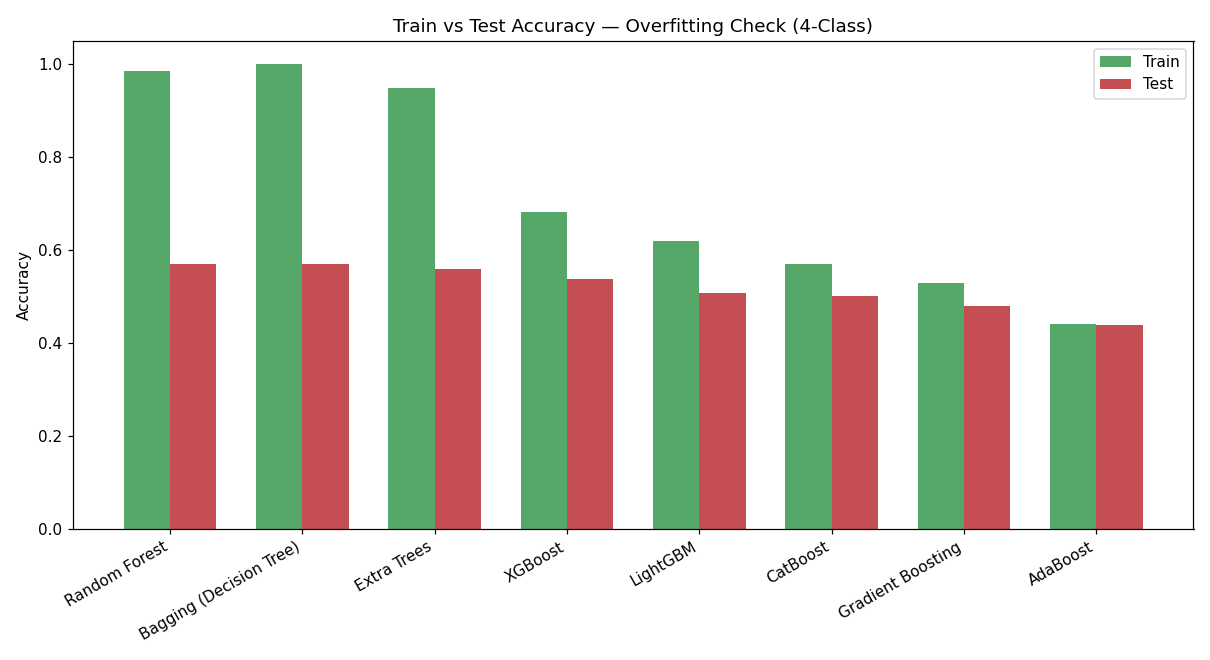

In [10]:
fig, ax = plt.subplots(figsize=(11,6))
x = np.arange(len(df4)); width = 0.35
ax.bar(x-width/2, df4['train_accuracy'], width, label='Train', color='#55A868')
ax.bar(x+width/2, df4['test_accuracy'], width, label='Test', color='#C44E52')
ax.set_xticks(x); ax.set_xticklabels(df4['model'], rotation=30, ha='right')
ax.set_ylabel('Accuracy'); ax.set_title('Train vs Test Accuracy -- Overfitting Check (4-Class)')
ax.legend(); plt.tight_layout()
plt.savefig("../outputs/figures/bagging_boosting_4class_overfit_gap.png", dpi=110)
plt.show()

print("Notice the pattern: full-depth Bagging-family trees memorize the training")
print("set (train acc ~95-100%) while Boosting-family models stay much closer to")
print("their test accuracy -- they generalize more honestly, even when their peak")
print("test accuracy is lower.")

## 3-Class Experiments

Repeating the same eight models on the 3-class reformulation (`05_ML_model_3.ipynb`),
which originally performed better for both Random Forest (67.86%) and XGBoost (65.68%).

In [11]:
models_3class = {}
for name in MODEL_ORDER:
    model, _ = train_and_evaluate(name, 3, X_train, y_train_3, X_test, y_test_3,
                                   class_names_3, "06_bagging_boosting_models.ipynb")
    models_3class[name] = model

[3-class][Random Forest] fit=31.2s  train_acc=0.9869  test_acc=0.6810  macro_f1=0.6703  weighted_f1=0.6711
[3-class][Bagging (Decision Tree)] fit=126.0s  train_acc=1.0000  test_acc=0.6746  macro_f1=0.6545  weighted_f1=0.6593
[3-class][Extra Trees] fit=10.9s  train_acc=0.9490  test_acc=0.6670  macro_f1=0.6625  weighted_f1=0.6628
[3-class][XGBoost] fit=9.1s  train_acc=0.7575  test_acc=0.6535  macro_f1=0.6343  weighted_f1=0.6327
[3-class][AdaBoost] fit=1.9s  train_acc=0.5391  test_acc=0.5408  macro_f1=0.5647  weighted_f1=0.5429
[3-class][Gradient Boosting] fit=80.6s  train_acc=0.6341  test_acc=0.6053  macro_f1=0.6147  weighted_f1=0.6058
[3-class][LightGBM] fit=3.9s  train_acc=0.6997  test_acc=0.6257  macro_f1=0.6314  weighted_f1=0.6247
[3-class][CatBoost] fit=13.9s  train_acc=0.6740  test_acc=0.6231  macro_f1=0.6292  weighted_f1=0.6227


In [12]:
ledger = pd.read_csv(RESULTS_PATH)
df3 = ledger[ledger.num_classes == 3].sort_values("test_accuracy", ascending=False).reset_index(drop=True)
df3["gap"] = (df3["train_accuracy"] - df3["test_accuracy"]).round(4)
print(df3[["model","family","train_accuracy","test_accuracy","macro_f1","weighted_f1","gap"]].to_string(index=False))

                  model   family  train_accuracy  test_accuracy  macro_f1  weighted_f1     gap
          Random Forest  Bagging          0.9869         0.6810    0.6703       0.6711  0.3059
Bagging (Decision Tree)  Bagging          1.0000         0.6746    0.6545       0.6593  0.3254
            Extra Trees  Bagging          0.9490         0.6670    0.6625       0.6628  0.2820
                XGBoost Boosting          0.7575         0.6535    0.6343       0.6327  0.1040
               LightGBM Boosting          0.6997         0.6257    0.6314       0.6247  0.0740
               CatBoost Boosting          0.6740         0.6231    0.6292       0.6227  0.0509
      Gradient Boosting Boosting          0.6341         0.6053    0.6147       0.6058  0.0288
               AdaBoost Boosting          0.5391         0.5408    0.5647       0.5429 -0.0017


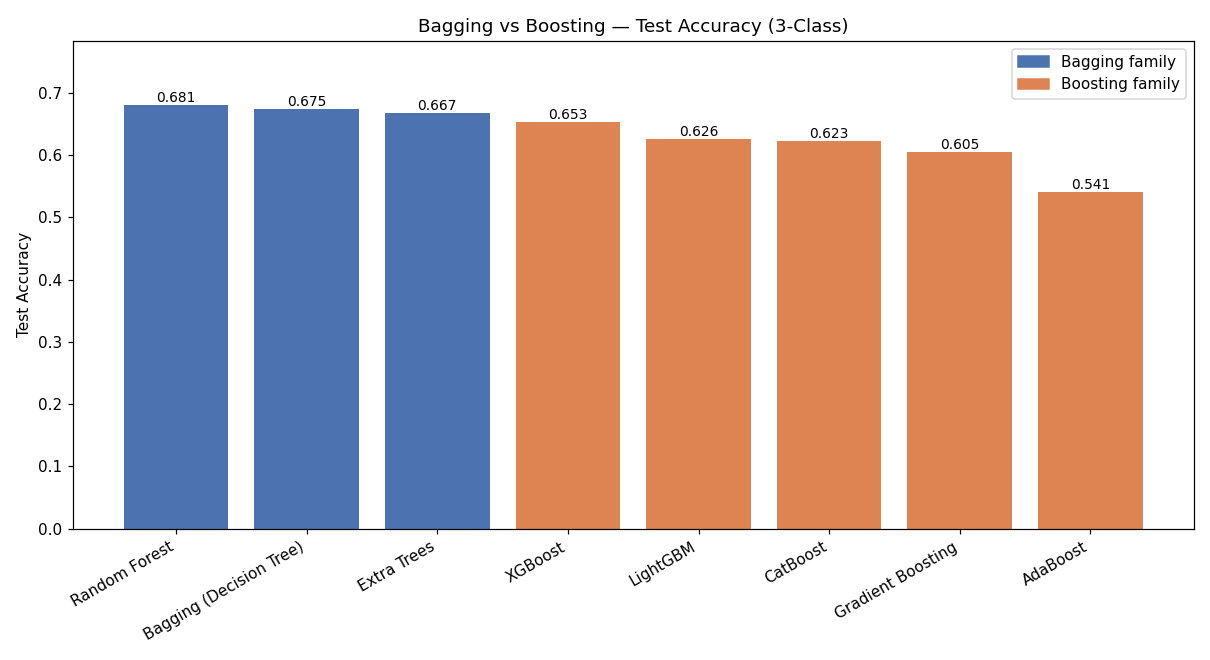

In [13]:
fig, ax = plt.subplots(figsize=(11,6))
colors = ['#4C72B0' if f=='Bagging' else '#DD8452' for f in df3['family']]
bars = ax.bar(df3['model'], df3['test_accuracy'], color=colors)
for b, v in zip(bars, df3['test_accuracy']):
    ax.text(b.get_x()+b.get_width()/2, v+0.005, f'{v:.3f}', ha='center', fontsize=9)
ax.set_ylabel('Test Accuracy'); ax.set_title('Bagging vs Boosting -- Test Accuracy (3-Class)')
ax.set_ylim(0, max(df3['test_accuracy'])*1.15)
plt.xticks(rotation=30, ha='right')
ax.legend(handles=[Patch(color='#4C72B0', label='Bagging family'), Patch(color='#DD8452', label='Boosting family')])
plt.tight_layout()
plt.savefig("../outputs/figures/bagging_boosting_3class_accuracy.png", dpi=110)
plt.show()

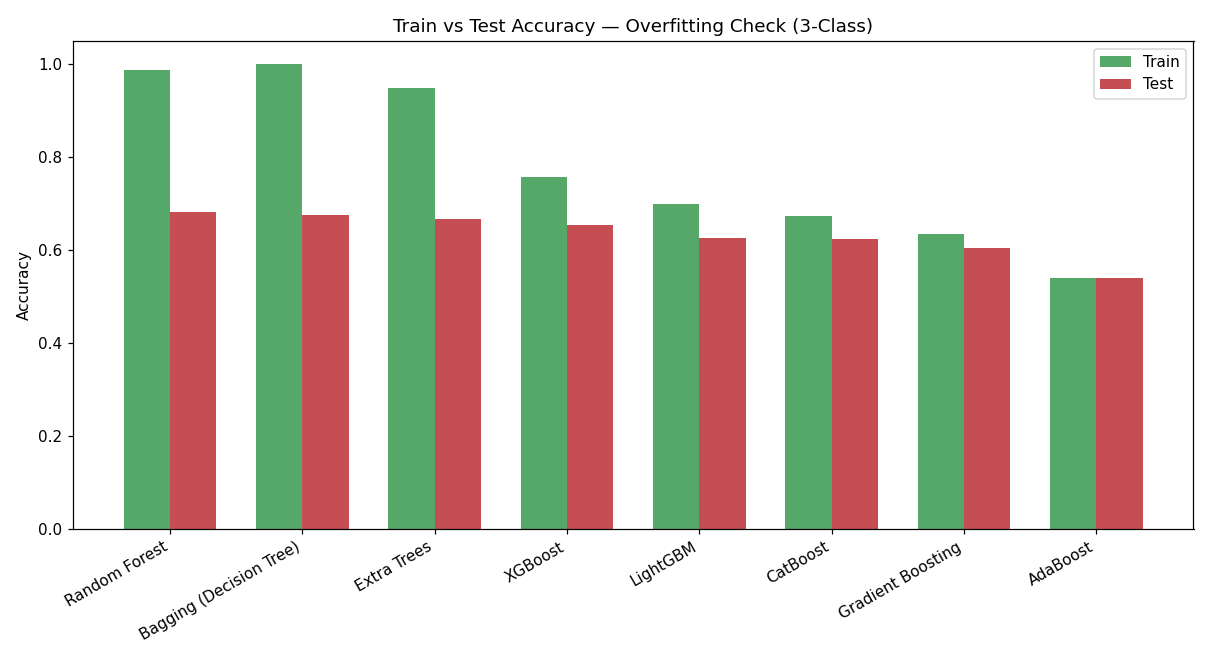

In [14]:
fig, ax = plt.subplots(figsize=(11,6))
x = np.arange(len(df3)); width = 0.35
ax.bar(x-width/2, df3['train_accuracy'], width, label='Train', color='#55A868')
ax.bar(x+width/2, df3['test_accuracy'], width, label='Test', color='#C44E52')
ax.set_xticks(x); ax.set_xticklabels(df3['model'], rotation=30, ha='right')
ax.set_ylabel('Accuracy'); ax.set_title('Train vs Test Accuracy -- Overfitting Check (3-Class)')
ax.legend(); plt.tight_layout()
plt.savefig("../outputs/figures/bagging_boosting_3class_overfit_gap.png", dpi=110)
plt.show()

## A closer look: best Bagging model vs. best Boosting model (3-Class)

Random Forest leads Bagging, XGBoost leads Boosting. Their per-class behavior looks
quite different even though their overall accuracy is only ~2.7 points apart.

In [16]:
for name in ["Random Forest", "XGBoost"]:
    pred = models_3class[name].predict(X_test)
    print("="*60)
    print(f"{name.upper()} (3-Class)")
    print("="*60)
    print(classification_report(y_test_3, pred, target_names=class_names_3))

RANDOM FOREST (3-Class)
              precision    recall  f1-score   support

    Low Risk       0.78      0.70      0.74      1867
 Medium Risk       0.64      0.46      0.53      3710
   High Risk       0.67      0.82      0.74      5625

    accuracy                           0.68     11202
   macro avg       0.70      0.66      0.67     11202
weighted avg       0.68      0.68      0.67     11202

XGBOOST (3-Class)
              precision    recall  f1-score   support

    Low Risk       0.83      0.67      0.74      1867
 Medium Risk       0.60      0.34      0.44      3710
   High Risk       0.63      0.85      0.73      5625

    accuracy                           0.65     11202
   macro avg       0.69      0.62      0.63     11202
weighted avg       0.66      0.65      0.63     11202



XGBoost is actually the more *precise* model for Low Risk (0.83 vs 0.78), but its
Medium Risk recall collapses to 0.34 -- it pushes a lot of Medium-Risk points into
High Risk. Random Forest is more balanced across all three classes, which is why it
wins on macro-F1 even though the gap in overall accuracy looks small.

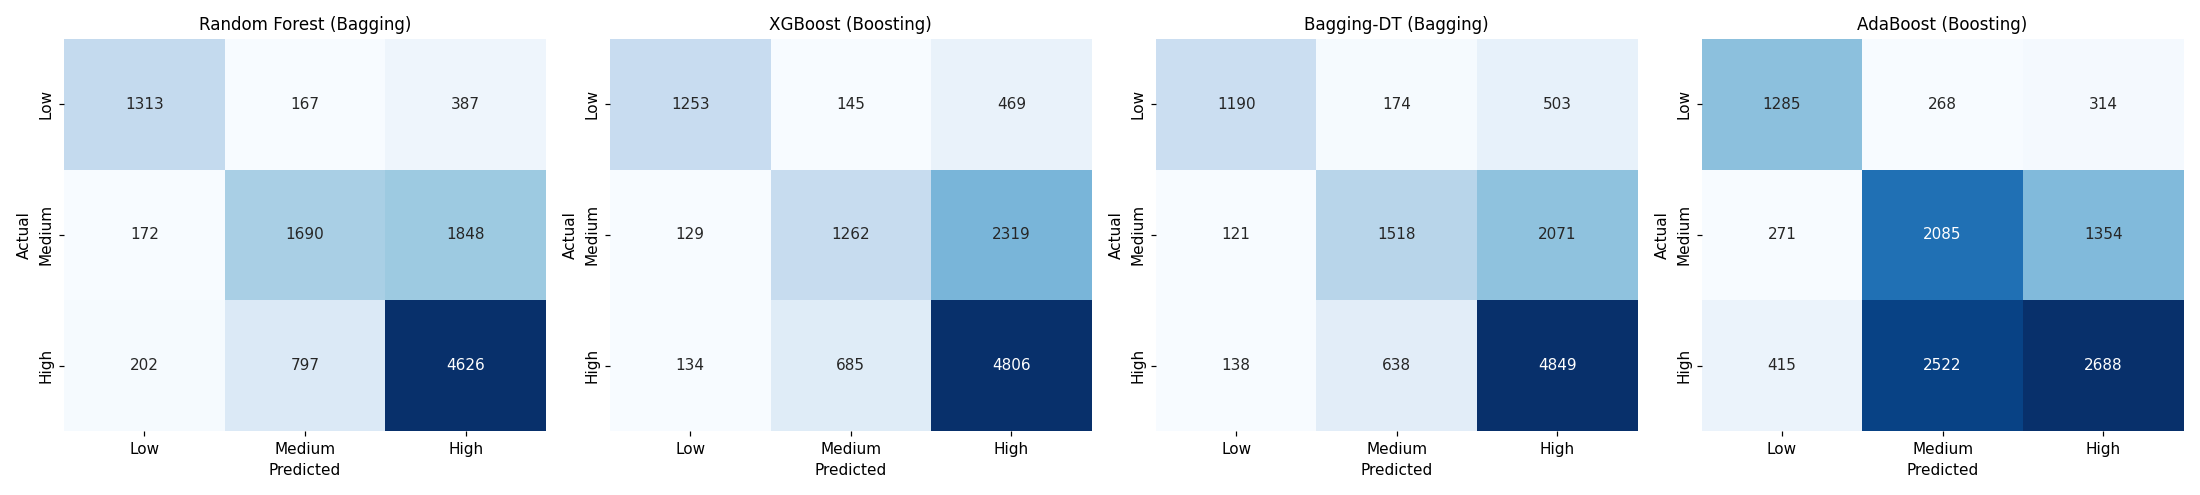

In [17]:
pairs = [("Random Forest", "Random Forest (Bagging)"), ("XGBoost", "XGBoost (Boosting)"),
         ("Bagging (Decision Tree)", "Bagging-DT (Bagging)"), ("AdaBoost", "AdaBoost (Boosting)")]

fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, (name, title) in zip(axes, pairs):
    pred = models_3class[name].predict(X_test)
    cm = confusion_matrix(y_test_3, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low','Medium','High'],
                yticklabels=['Low','Medium','High'], ax=ax, cbar=False)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig("../outputs/figures/bagging_boosting_confusion_matrices_3class.png", dpi=110)
plt.show()

## Family-level comparison

Averaging across all models within each family, for each class scheme.

                        test_accuracy  macro_f1
num_classes family                             
3           Bagging            0.6742    0.6624
3           Boosting           0.5897    0.5945
4           Bagging            0.5661    0.5468
4           Boosting           0.4930    0.4834


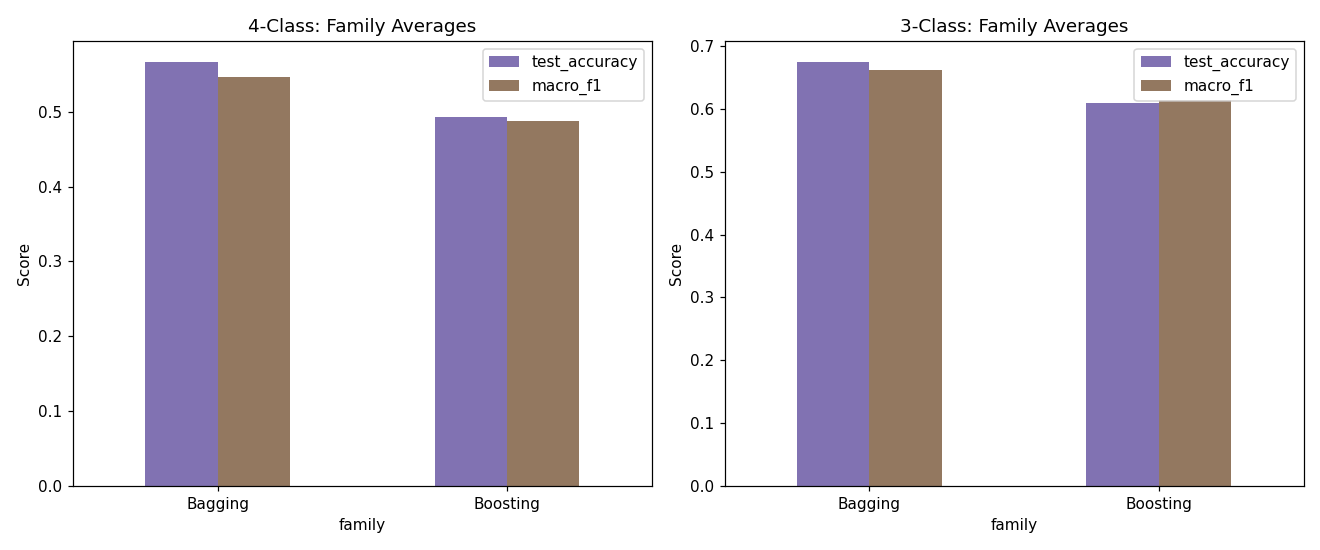

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for i, nc in enumerate([4, 3]):
    sub = ledger[ledger.num_classes == nc]
    fam = sub.groupby("family")[["test_accuracy", "macro_f1"]].mean()
    fam.plot(kind="bar", ax=axes[i], color=["#8172B2", "#937860"])
    axes[i].set_title(f"{nc}-Class: Family Averages")
    axes[i].set_ylabel("Score")
    axes[i].tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.savefig("../outputs/figures/bagging_vs_boosting_family_avg.png", dpi=110)
plt.show()

fam_summary = ledger.groupby(["num_classes","family"])[["test_accuracy","macro_f1"]].mean().round(4)
print(fam_summary)

## Key findings from this phase

1. **Bagging beat Boosting on this dataset, in both class schemes.** Average test
   accuracy: Bagging 67.4% vs Boosting 59.0% (3-class); 56.6% vs 49.3% (4-class).
   Random Forest remains the single best model overall.

2. **But Boosting models overfit far less.** The Bagging family's full-depth trees
   hit 95-100% training accuracy (a 28-43 point train/test gap). AdaBoost, the
   weakest performer, has essentially a *zero* gap -- it isn't overfitting at all,
   it's just a lower-capacity model for this feature set. Gradient Boosting, LightGBM
   and CatBoost sit in between: meaningfully better generalization than Bagging,
   meaningfully worse peak accuracy than Random Forest.

3. **CatBoost and LightGBM land close to XGBoost**, confirming the "Future Work:
   CatBoost benchmarking" item from the README was a reasonable direction, even
   though it didn't unseat XGBoost as the best boosting model here.

4. **AdaBoost is the weakest model in the whole comparison.** With only 23 mostly
   correlated/noisy geospatial features (recall `slope <-> roughness: 0.95` and
   `rainfall_7day <-> rainfall_15day: 1.00` from the correlation check in
   `05_ML_model_3.ipynb`), AdaBoost's sensitivity to noisy/hard examples likely hurts
   it more than the other boosting methods, which is a well-documented weakness of
   SAMME-style boosting on this kind of tabular data.

5. **The 3-class reformulation continues to help every single model**, not just
   Random Forest/XGBoost -- reinforcing that collapsing "Vulnerable" and
   "High Vulnerability" together (classes that were hardest to tell apart) was
   the right call.

All 16 results (8 models x 2 class schemes) are saved in
`../outputs/results/model_results.csv` alongside the MLP baseline, ready for
`08_final_comparison.ipynb` once the CNN model (`07_cnn_image_model.ipynb`) is added.

In [19]:
final_check = pd.read_csv(RESULTS_PATH)
print(f"Ledger now has {len(final_check)} rows spanning "
      f"{final_check['num_classes'].nunique()} class schemes and "
      f"{final_check['model'].nunique()} distinct models.")
print(sorted(final_check['model'].unique()))

Ledger now has 17 rows spanning 2 class schemes and 9 distinct models.
['AdaBoost', 'Bagging (Decision Tree)', 'CatBoost', 'Extra Trees', 'Gradient Boosting', 'LightGBM', 'MLP', 'Random Forest', 'XGBoost']
